# Fed Funds & Treasury Yield Curve

--- 

- FRED URL : https://fred.stlouisfed.org/

---

In [5]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import requests

In [6]:
 # function to get Fred API data

def get_data(series_id):#, start_date, end_date="9999-12-31"):
    web = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": "d89938f81b6bd4dc1dc7b9db5f33703f",
        "file_type": "json",
        # "observation_start": start_date,
        # "observation_end": end_date
    }
    data = requests.get(web, params=params).json()
    
    df = pd.DataFrame(data['observations'], columns=['date', 'value'])
    df = df.set_index('date')
    df.index = pd.to_datetime(df.index)
    df.columns = [series_id]

    df[series_id] = df[series_id].replace('.', np.nan).ffill().astype('float')
    df = df.dropna()

    return df

#### **Daily U.S. Treasury Series ID list**

|Maturity	|Series ID |Description |
|:-|:-|:-|
|1개월	|DGS1MO  |1-Month Treasury Constant Maturity Rate|
|3개월	|DGS3MO	 |3-Month Treasury Constant Maturity Rate|
|6개월	|DGS6MO	 |6-Month Treasury Constant Maturity Rate|
|1년	|DGS1	 |1-Year Treasury Constant Maturity Rate|
|2년	|DGS2	 |2-Year Treasury Constant Maturity Rate|
|10년	|DGS10	 |10-Year Treasury Constant Maturity Rate|

In [7]:
# Create US Treasury Dataframe

def create_df_ust():

    # create a dictionary for mapping tenors. {series_id: tenors}
    dict_tenors = {
        "DFEDTARL": "FFLo",
        "DFEDTARU": "FFUp",
        "EFFR": "ON",
        "DGS1MO": "1M",
        "DGS3MO": "3M",
        "DGS6MO": "6M",
        "DGS1": "1Y",
        "DGS2": "2Y",
        "DGS5": "5Y",
        "DGS7": "7Y",
        "DGS10": "10Y",
        "DGS20": "20Y",
        "DGS30": "30Y",
    }

    # series_id 리스트 생성
    list_tenors = list(dict_tenors.keys())

    # 데이터 담을 데이터프레임 생성
    df_ust = pd.DataFrame()

    for tenor in list_tenors:
        df = get_data(tenor)#, start_date, end_date)
        df_ust = pd.concat([df_ust, df], axis=1)

    # df_yield 컬럼명을 description(dict's value)으로 변경
    df_ust = df_ust.rename(columns=dict_tenors)
    df_ust = df_ust.dropna()

    return df_ust

In [8]:
# df_ust 생성 및 요약
df_ust = create_df_ust()

print(
    " ============= Data Summary ============= ",
    "\n 1. Total Count   :", len(df_ust),
    "\n 2. Count Nulls   :", df_ust.isna().sum().sum(),
    "\n 3. Period Begins :", df_ust.index[0].strftime('%Y-%m-%d'),
    "\n 4. Period Ends   :", df_ust.index[-1].strftime('%Y-%m-%d'),
    "\n 5. Columns :", list(df_ust.columns)
)

 ============= Data Summary =============  
 1. Total Count   : 4497 
 2. Count Nulls   : 0 
 3. Period Begins : 2008-12-16 
 4. Period Ends   : 2026-03-11 
 5. Columns : ['FFLo', 'FFUp', 'ON', '1M', '3M', '6M', '1Y', '2Y', '5Y', '7Y', '10Y', '20Y', '30Y']


In [9]:
# Graph Yield Curve & Spread

def graph_curve_spread(date_1, date_2):
    ''' parameter: date_1(최신), date_2(과거) 는 yyyy-mm-dd 포맷으로 입력 '''

    # df_ust: US Treasury DataFrame. create_df_ust() 함수 활용 시 아래 활성화
    # df_ust = create_df_ust()

    # tenors 축출 = df_ust의 컬럼명. 단 columns[0, 1]은 제외 - (FFLo, FFUp)
    tenors = list(df_ust.columns[2:])
    
    yld_curve_dt1 = df_ust.loc[date_1, tenors].T
    yld_curve_dt2 = df_ust.loc[date_2, tenors].T
    spread = yld_curve_dt1 - yld_curve_dt2
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                   gridspec_kw={'height_ratios':[2, 1], 'hspace': 0.05})
    
    ax1.plot(yld_curve_dt1, label=date_1, marker='o')
    ax1.plot(yld_curve_dt2, label=date_2, marker='o', color='grey', linestyle='--', alpha=0.4)

    # plot 차트 위 yld_curve_dt1의 값 표현
    for x, y in zip(yld_curve_dt1.index, yld_curve_dt1.values):
        ax1.text(x, y + 0.10, f"{y:.2f}", color='#1f77b4', fontweight='bold', ha='center', fontsize=10)

    bars = ax2.bar(tenors, spread, color='g', width=0.5, alpha=0.8)

    # bar 차트 위 spread 값 표현
    for rect in bars:
        height = rect.get_height()
        ax2.text(
            rect.get_x() + rect.get_width()/2,     # x 위치
            height + (0.001 if height > 0 else -0.001),  # y 위치 (양수/음수에 따라 위/아래)
            f"{height:.2f}",                      # 표시할 값
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=9, color='darkgreen'
        )
    
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.2)
    ax2.grid(True, alpha=0.2)

    # 차트 상하 버퍼 적용
    ax1.margins(y=0.20)
    ax2.margins(y=0.20)
    
    ax1.set_title("US Yield Curve & Spread", fontsize=16)

    plt.show()

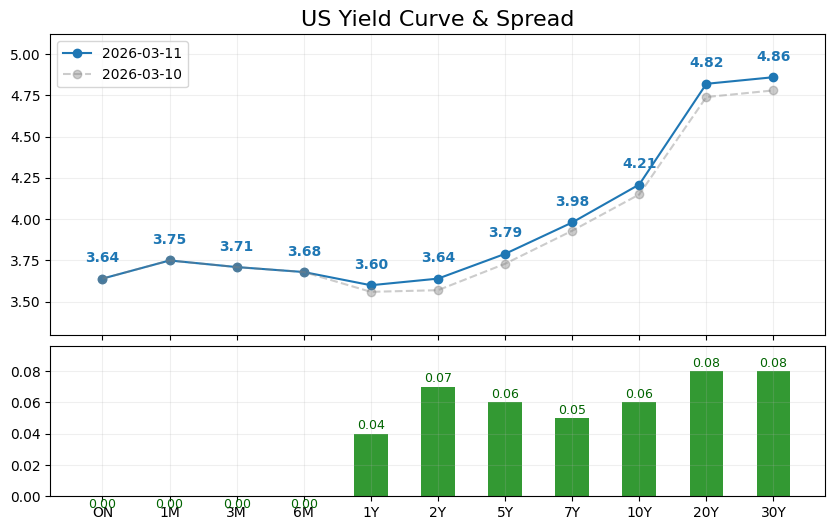

In [10]:
dt_tod = (df_ust.index[-1]).strftime("%Y-%m-%d")
dt_pbd = (df_ust.index[-2]).strftime("%Y-%m-%d")

graph_curve_spread(dt_tod, dt_pbd)

In [11]:
# Ticker 정의
ticker_list = list(df_ust.columns[2:])

# 데이터 기준일
start_date = "2019-01-01"
end_date = "2020-12-31"

# 데이터프레임
df_part = df_ust.copy()
df_part = df_part[start_date : end_date]

df_part.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 523 entries, 2019-01-01 to 2020-12-31
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FFLo    523 non-null    float64
 1   FFUp    523 non-null    float64
 2   ON      523 non-null    float64
 3   1M      523 non-null    float64
 4   3M      523 non-null    float64
 5   6M      523 non-null    float64
 6   1Y      523 non-null    float64
 7   2Y      523 non-null    float64
 8   5Y      523 non-null    float64
 9   7Y      523 non-null    float64
 10  10Y     523 non-null    float64
 11  20Y     523 non-null    float64
 12  30Y     523 non-null    float64
dtypes: float64(13)
memory usage: 57.2 KB


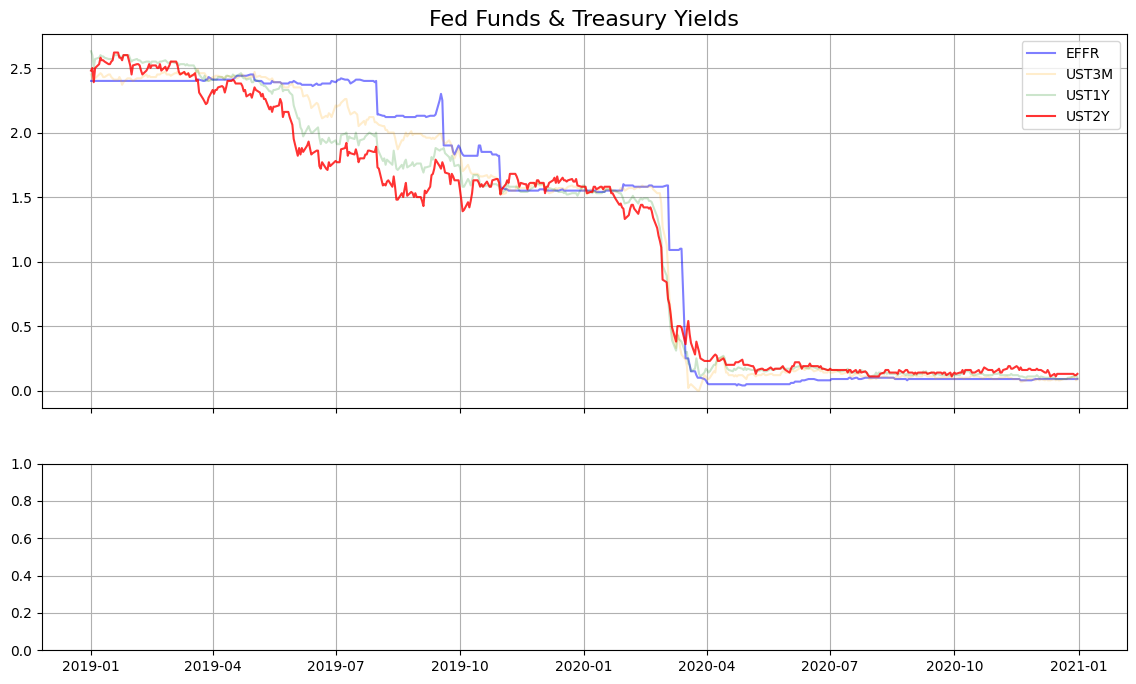

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=(1.0, 0.5), sharex=True)

ax1.plot(df_part['ON'], label='EFFR', color='blue', alpha=0.5)
ax1.plot(df_part['3M'], label='UST3M', color='orange', alpha=0.2)
ax1.plot(df_part['1Y'], label='UST1Y', color='green', alpha=0.2)
ax1.plot(df_part['2Y'], label='UST2Y', color='red', alpha=0.8)

ax1.grid(True)
ax2.grid(True)

ax1.set_title("Fed Funds & Treasury Yields", fontsize=16)
ax1.legend(loc='best')

plt.show()

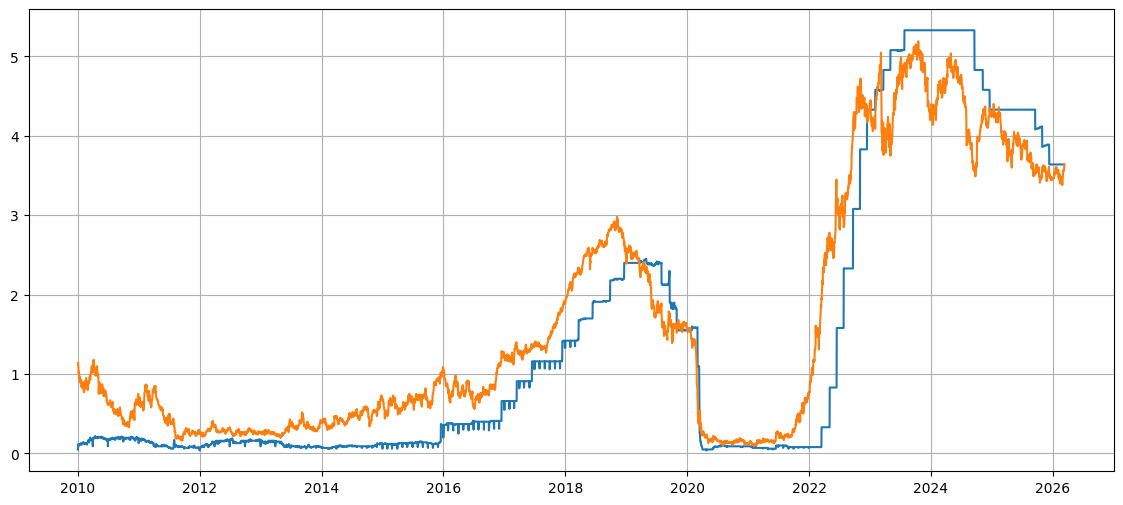

In [13]:
temp = df_ust.loc['2010':][['ON', '2Y']]

plt.figure(figsize=(14, 6))
plt.plot(temp)

plt.grid(True)
plt.show()

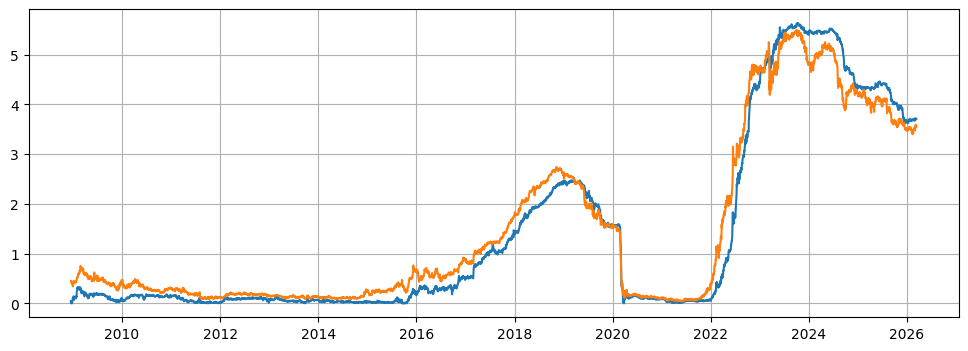

In [14]:
temp = df_ust.copy()

temp['UST1Y_SH'] = temp['1Y'].shift()

plt.figure(figsize=(12, 4))
plt.plot(temp[['3M', 'UST1Y_SH']])
plt.grid(True)
plt.show()

In [15]:
temp.tail()

,FFLo,FFUp,ON,1M,3M,6M,1Y,2Y,5Y,7Y,10Y,20Y,30Y,UST1Y_SH
date,,,,,,,,,,,,,,
2026-03-05,3.5,3.75,3.64,3.75,3.70,3.68,3.59,3.57,3.72,3.92,4.13,4.71,4.74,3.58
2026-03-06,3.5,3.75,3.64,3.75,3.69,3.66,3.55,3.56,3.72,3.93,4.15,4.74,4.77,3.59
2026-03-09,3.5,3.75,3.64,3.75,3.71,3.68,3.56,3.56,3.71,3.90,4.12,4.70,4.72,3.55
2026-03-10,3.5,3.75,3.64,3.75,3.71,3.68,3.56,3.57,3.73,3.93,4.15,4.74,4.78,3.56
2026-03-11,3.5,3.75,3.64,3.75,3.71,3.68,3.60,3.64,3.79,3.98,4.21,4.82,4.86,3.56


In [16]:
temp["imp_fwd"] = ((((df_ust['2Y']/100 + 1)**2) /( df_ust['1Y']/100 + 1)) - 1) * 100

In [17]:
temp['imp_fwd'] = temp['imp_fwd'].shift(252)

In [18]:
temp.dropna()

,FFLo,FFUp,ON,1M,3M,6M,1Y,2Y,5Y,7Y,10Y,20Y,30Y,UST1Y_SH,imp_fwd
date,,,,,,,,,,,,,,,
2009-12-03,0.0,0.25,0.13,0.09,0.06,0.16,0.30,0.74,2.14,2.87,3.39,4.23,4.33,0.28,0.850398
2009-12-04,0.0,0.25,0.12,0.08,0.06,0.17,0.36,0.84,2.24,2.97,3.48,4.31,4.40,0.30,1.010780
2009-12-07,0.0,0.25,0.12,0.07,0.04,0.16,0.32,0.78,2.19,2.92,3.44,4.29,4.40,0.36,0.930622
2009-12-08,0.0,0.25,0.12,0.02,0.03,0.15,0.29,0.73,2.12,2.86,3.40,4.28,4.39,0.32,1.040896
2009-12-09,0.0,0.25,0.12,0.01,0.03,0.14,0.31,0.76,2.15,2.89,3.45,4.31,4.41,0.29,1.342200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-05,3.5,3.75,3.64,3.75,3.70,3.68,3.59,3.57,3.72,3.92,4.13,4.71,4.74,3.58,3.950078
2026-03-06,3.5,3.75,3.64,3.75,3.69,3.66,3.55,3.56,3.72,3.93,4.15,4.74,4.77,3.59,3.880116
2026-03-09,3.5,3.75,3.64,3.75,3.71,3.68,3.56,3.56,3.71,3.90,4.12,4.70,4.72,3.55,3.840116


In [19]:
plt.style.use("seaborn-v0_8")

date
2026-03-05    3.550004
2026-03-06    3.570001
2026-03-09    3.560000
2026-03-10    3.580001
2026-03-11    3.680015
dtype: float64 



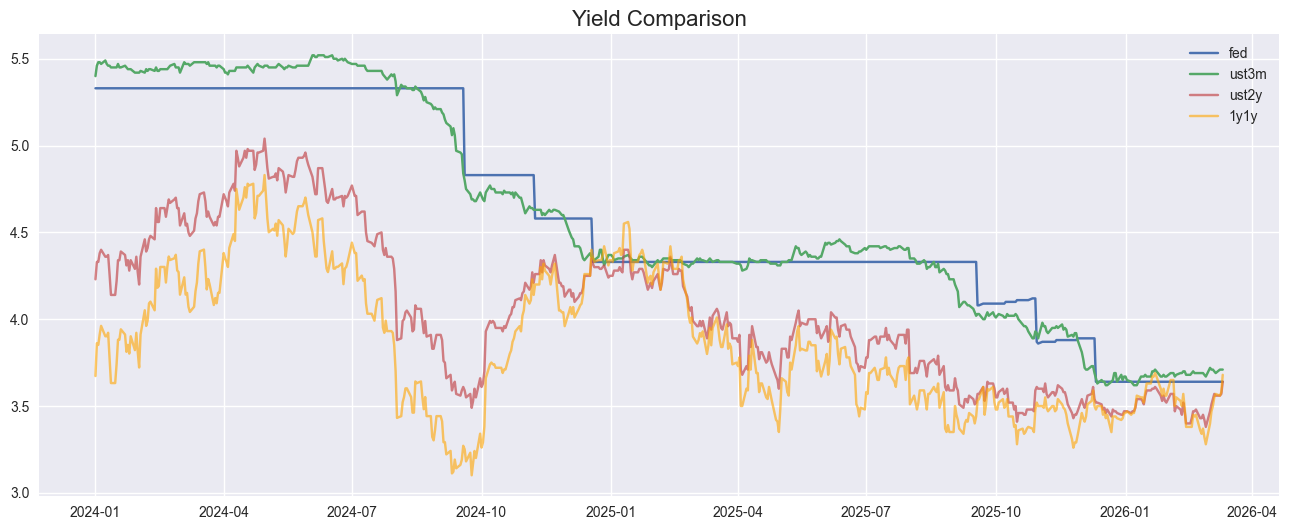

In [20]:
# implied forward 1y1y rate
# implied_fwd = df_ust['2Y'] ** 2 / df_ust['1Y']

start_year = '2024'

implied_fwd = ((((df_ust['2Y']/100 + 1)**2) /( df_ust['1Y']/100 + 1)) - 1) * 100
implied_fwd = implied_fwd[start_year:]

print(implied_fwd.tail(), "\n")

plt.figure(figsize=(16, 6))
plt.plot(df_ust.loc[start_year:,'ON'], label='fed')
plt.plot(df_ust.loc[start_year:,'3M'], label='ust3m')
plt.plot(df_ust.loc[start_year:,'2Y'], label='ust2y', alpha=0.7)
plt.plot(implied_fwd, label='1y1y', alpha=0.6, color='orange')

plt.title("Yield Comparison", fontsize=16)
plt.grid(True)
plt.legend()

import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.show()

In [23]:
import plotly.express as px

df_plot = df_ust.loc[start_year:, ['ON', '1Y', '2Y']].copy()
df_plot['imp fwd'] = implied_fwd.reindex(df_plot.index)

fig = px.line(
    df_plot,
    x=df_plot.index,
    y=['ON', '1Y', '2Y', 'imp fwd'],
    labels={'value': 'Yield', 'variable': 'Series'},
    template='plotly_white'
)

# imp fwd만 투명도 적용
fig.update_traces(selector=dict(name='imp fwd'), opacity=0.6)

fig.update_layout(
    width=1000,
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=40, r=20, t=30, b=30)
)

# seaborn 스타일 느낌: 연한 회색 배경 + 하얀 그리드
fig.update_layout(
    plot_bgcolor='#EAEAF2',
    paper_bgcolor='#EAEAF2'
)

fig.update_xaxes(showgrid=True, gridcolor='white', zerolinecolor='white')
fig.update_yaxes(showgrid=True, gridcolor='white', zerolinecolor='white')
fig.update_yaxes(tickformat=".1f")

fig.show()
